In [3]:
import pandas as pd
from pathlib import Path

ipums_df = pd.read_pickle(Path("outputs/cache/ipums_df.pkl"))

ipums_df.shape

(16095728, 61)

In [4]:
# Add weeks worked last year from the separate IPUMS extract.
weeks_worked_cache = Path("outputs/cache/weeks_worked_lookup.pkl")
weeks_worked_path = Path("data/hours_worked.dat")

if "WKSWORK1" not in ipums_df.columns:
    if weeks_worked_cache.exists():
        weeks_worked_lookup = pd.read_pickle(weeks_worked_cache)
    else:
        weeks_worked_lookup = pd.read_fwf(
            weeks_worked_path,
            colspecs=[(8, 14), (14, 22), (71, 75), (85, 87)],
            names=["SAMPLE", "SERIAL", "PERNUM", "WKSWORK1"],
        )
        weeks_worked_lookup["WKSWORK1"] = (
            pd.to_numeric(weeks_worked_lookup["WKSWORK1"], errors="coerce")
            .replace(0, pd.NA)
            .astype("Int64")
        )
        weeks_worked_lookup.to_pickle(weeks_worked_cache)

    merge_keys = ["SAMPLE", "SERIAL", "PERNUM"]
    for key in merge_keys:
        ipums_df[key] = pd.to_numeric(ipums_df[key], errors="coerce").astype("Int64")
        weeks_worked_lookup[key] = pd.to_numeric(
            weeks_worked_lookup[key], errors="coerce"
        ).astype("Int64")

    ipums_df = ipums_df.merge(
        weeks_worked_lookup[merge_keys + ["WKSWORK1"]],
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )

print(f"WKSWORK1 merged for {ipums_df['WKSWORK1'].notna().sum():,} records.")

WKSWORK1 merged for 8,257,087 records.


In [5]:
# Prepare ACS person weights so downstream results represent the full U.S. population
WEIGHT_COL = 'PERWT_num'
ipums_df[WEIGHT_COL] = pd.to_numeric(ipums_df.get('PERWT', 0), errors='coerce').fillna(0)

def weighted_total(df, weight_col=WEIGHT_COL):
    return df[weight_col].sum()

def weighted_counts(df, group_col, weight_col=WEIGHT_COL, dropna=True):
    counts = (
        df.groupby(group_col, dropna=dropna)[weight_col]
        .sum()
        .sort_values(ascending=False)
    )
    return counts

def weighted_mask_total(df, mask, weight_col=WEIGHT_COL):
    return df.loc[mask, weight_col].sum()

print(f"Added numeric ACS person weights in column '{WEIGHT_COL}'.")
print(f"Weighted total represented by loaded sample: {weighted_total(ipums_df):,.0f}")

Added numeric ACS person weights in column 'PERWT_num'.
Weighted total represented by loaded sample: 334,922,503


# Residual Method and Refinements for Estimating Documentation Status

In [6]:
#Drop all except ages 18-64.
ipums_df = ipums_df[ipums_df['AGE'].between(18, 64, inclusive='both')]

- Step 1: Restrict to Foreign Born Population

In [7]:
#ACS vs CPS
foreign_born_df = ipums_df[pd.to_numeric(ipums_df.get('BPL'), errors='coerce') >= 150]

- Step 2: Assign likely legal if immigrated pre-1980

In [8]:
foreign_born_df['likely_legal'] = foreign_born_df['YRIMMIG'] <= 1980

C:\Users\linds\AppData\Local\Temp\ipykernel_41556\36336273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['YRIMMIG'] <= 1980


- Step 3: Assign likely legal if utilizing benefits

In [9]:
#ACS
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCSS', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCSUP', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCWELFR', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)

C:\Users\linds\AppData\Local\Temp\ipykernel_41556\2260069458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('INCSS', pd.Series(0, index=foreign_born_df.index)), errors='coerce').fillna(0) > 0)
C:\Users\linds\AppData\Local\Temp\ipykernel_41556\2260069458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df

- Step 4: Assign likely legal if veteran

In [10]:
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('VETSTAT', 0), errors='coerce') == 2)

C:\Users\linds\AppData\Local\Temp\ipykernel_41556\2196620341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('VETSTAT', 0), errors='coerce') == 2)


- Step 5: Assign likely legal if receiving Medicaid or Medicare

In [11]:
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCAID', 0), errors='coerce') ==2)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCARE', 0), errors='coerce') ==2)

C:\Users\linds\AppData\Local\Temp\ipykernel_41556\2553262492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCAID', 0), errors='coerce') ==2)
C:\Users\linds\AppData\Local\Temp\ipykernel_41556\2553262492.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('HINSCARE', 0), errors='coerce') ==2)


- Step 6: Assign likely legal if federal employee

In [12]:
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==25)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==26)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==27)
foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==28)

C:\Users\linds\AppData\Local\Temp\ipykernel_41556\182117834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==25)
C:\Users\linds\AppData\Local\Temp\ipykernel_41556\182117834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | (pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce') ==26)
C:\U

- Step 7: Apply naturalization refinement

In [13]:
# Step 7: citizenship-based likely legal designation with a naturalization-timing refinement
likely_legal_before_step7 = foreign_born_df['likely_legal'].copy()
citizen_numeric = pd.to_numeric(foreign_born_df.get('CITIZEN', 0), errors='coerce')
survey_year_numeric = pd.to_numeric(foreign_born_df.get('YEAR', pd.Series(index=foreign_born_df.index)), errors='coerce')
yrimmig_numeric = pd.to_numeric(foreign_born_df.get('YRIMMIG', pd.Series(index=foreign_born_df.index)), errors='coerce')
years_in_us = survey_year_numeric - yrimmig_numeric

citizen_reported_mask = citizen_numeric <= 2

spouse_citizen_map = {}
for idx, row in foreign_born_df.iterrows():
    raw_citizen = pd.to_numeric(row.get('CITIZEN', None), errors='coerce')
    spouse_citizen_map[(row['CBSERIAL'], row['PERNUM'])] = pd.notna(raw_citizen) and raw_citizen <= 2

def is_married_to_us_citizen(row):
    if pd.isna(row['SPLOC']) or row['SPLOC'] == 0:
        return False
    return spouse_citizen_map.get((row['CBSERIAL'], row['SPLOC']), False)

spouse_is_citizen = foreign_born_df.apply(is_married_to_us_citizen, axis=1)
citizen_naturalization_rule_mask = citizen_reported_mask & (
    (years_in_us >= 5) |
    ((years_in_us >= 3) & spouse_is_citizen)
)

step7_adds_all_citizens = citizen_reported_mask & ~likely_legal_before_step7
step7_adds_rule_citizens = citizen_naturalization_rule_mask & ~likely_legal_before_step7

likely_legal_all_citizens = likely_legal_before_step7 | citizen_reported_mask
likely_legal_rule_citizens = likely_legal_before_step7 | citizen_naturalization_rule_mask

print('Step 7 weighted comparison: all reported citizens vs naturalization timing rule')
print(f"Added to likely legal if all reported citizens count as legal: {weighted_mask_total(foreign_born_df, step7_adds_all_citizens):,.0f}")
print(f"Added to likely legal with 5-year / 3-year married-to-citizen rule: {weighted_mask_total(foreign_born_df, step7_adds_rule_citizens):,.0f}")
print(f"Difference in Step 7 additions from applying your rule: {weighted_mask_total(foreign_born_df, step7_adds_all_citizens) - weighted_mask_total(foreign_born_df, step7_adds_rule_citizens):,.0f}")
print()
print(f"Total likely legal if all reported citizens count as legal: {weighted_mask_total(foreign_born_df, likely_legal_all_citizens):,.0f}")
print(f"Total likely unauthorized if all reported citizens count as legal: {weighted_total(foreign_born_df) - weighted_mask_total(foreign_born_df, likely_legal_all_citizens):,.0f}")
print(f"Total likely legal with 5-year / 3-year married-to-citizen rule: {weighted_mask_total(foreign_born_df, likely_legal_rule_citizens):,.0f}")
print(f"Total likely unauthorized with 5-year / 3-year married-to-citizen rule: {weighted_total(foreign_born_df) - weighted_mask_total(foreign_born_df, likely_legal_rule_citizens):,.0f}")

foreign_born_df['likely_legal'] = likely_legal_rule_citizens

Step 7 weighted comparison: all reported citizens vs naturalization timing rule
Added to likely legal if all reported citizens count as legal: 13,506,363
Added to likely legal with 5-year / 3-year married-to-citizen rule: 13,413,740
Difference in Step 7 additions from applying your rule: 92,623

Total likely legal if all reported citizens count as legal: 23,842,624
Total likely unauthorized if all reported citizens count as legal: 14,778,785
Total likely legal with 5-year / 3-year married-to-citizen rule: 23,750,001
Total likely unauthorized with 5-year / 3-year married-to-citizen rule: 14,871,408


C:\Users\linds\AppData\Local\Temp\ipykernel_41556\309061402.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = likely_legal_rule_citizens


- Step 8: Apply licensing refinement

In [14]:
likely_legal_before_step9 = foreign_born_df['likely_legal'].copy()
occ_numeric = pd.to_numeric(foreign_born_df.get('OCC', 0), errors='coerce').fillna(0)

in_licensed_occ_range = (
    ((occ_numeric >= 2200) & (occ_numeric <= 3540)) |  # Healthcare Practitioners
    ((occ_numeric >= 3700) & (occ_numeric <= 3950)) |  # Protective Service
    ((occ_numeric >= 2100) & (occ_numeric <= 2160)) |  # Legal
    ((occ_numeric >= 2300) & (occ_numeric <= 2550)) |  # Education
    ((occ_numeric >= 9030) & (occ_numeric <= 9040)) |  # Aviation/Transport
    ((occ_numeric >= 1300) & (occ_numeric <= 1560))    # Engineering/Arch
)

# Refinement: do NOT apply this licensed-occupation legal rule in:
# CA, CO, DE, IL, NV, NJ, VT
exempt_statefip = {6, 8, 10, 17, 32, 34, 50}
statefip_numeric = pd.to_numeric(
    foreign_born_df.get('STATEFIP', pd.Series(index=foreign_born_df.index)),
    errors='coerce'
)

licensed_rule_applies = ~statefip_numeric.isin(exempt_statefip)
licensed_mask_without_exceptions = in_licensed_occ_range
licensed_mask_with_exceptions = in_licensed_occ_range & licensed_rule_applies

step9_adds_without_exceptions = licensed_mask_without_exceptions & ~likely_legal_before_step9
step9_adds_with_exceptions = licensed_mask_with_exceptions & ~likely_legal_before_step9

likely_legal_without_exceptions = likely_legal_before_step9 | licensed_mask_without_exceptions
likely_legal_with_exceptions = likely_legal_before_step9 | licensed_mask_with_exceptions

print('Step 9 weighted comparison: licensed occupations with vs without your state exceptions')
print(f"Added to likely legal without exceptions: {weighted_mask_total(foreign_born_df, step9_adds_without_exceptions):,.0f}")
print(f"Added to likely legal with exceptions: {weighted_mask_total(foreign_born_df, step9_adds_with_exceptions):,.0f}")
print(f"Difference in Step 9 additions due to exceptions: {weighted_mask_total(foreign_born_df, step9_adds_without_exceptions) - weighted_mask_total(foreign_born_df, step9_adds_with_exceptions):,.0f}")
print()
print(f"Likely legal total without exceptions: {weighted_mask_total(foreign_born_df, likely_legal_without_exceptions):,.0f}")
print(f"Likely unauthorized total without exceptions: {weighted_total(foreign_born_df) - weighted_mask_total(foreign_born_df, likely_legal_without_exceptions):,.0f}")
print(f"Likely legal total with exceptions: {weighted_mask_total(foreign_born_df, likely_legal_with_exceptions):,.0f}")
print(f"Likely unauthorized total with exceptions: {weighted_total(foreign_born_df) - weighted_mask_total(foreign_born_df, likely_legal_with_exceptions):,.0f}")

foreign_born_df['likely_legal'] = likely_legal_with_exceptions

C:\Users\linds\AppData\Local\Temp\ipykernel_41556\4047452749.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = likely_legal_with_exceptions


Step 9 weighted comparison: licensed occupations with vs without your state exceptions
Added to likely legal without exceptions: 1,600,166
Added to likely legal with exceptions: 1,148,364
Difference in Step 9 additions due to exceptions: 451,802

Likely legal total without exceptions: 25,350,167
Likely unauthorized total without exceptions: 13,271,242
Likely legal total with exceptions: 24,898,365
Likely unauthorized total with exceptions: 13,723,044


- Step 10: Apply H1B visa rule

In [15]:
educ_numeric = pd.to_numeric(foreign_born_df.get('EDUC', 0), errors='coerce').fillna(0)
yrimmig_numeric = pd.to_numeric(foreign_born_df.get('YRIMMIG', foreign_born_df.get('yrimmig', 0)), errors='coerce').fillna(0)

h1b_likely_legal = (educ_numeric >= 10) & (yrimmig_numeric >= 2020)
foreign_born_df.loc[:, 'likely_legal'] = foreign_born_df['likely_legal'] | h1b_likely_legal

* Step 11: Apply spouse rule

In [16]:
legal_map = {}
for idx, row in foreign_born_df.iterrows():
    legal_map[(row['CBSERIAL'], row['PERNUM'])] = row['likely_legal']

# Check if spouse is legal
def is_spouse_legal(row):
    if pd.isna(row['SPLOC']) or row['SPLOC'] == 0:
        return False
    return legal_map.get((row['CBSERIAL'], row['SPLOC']), False)

foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | foreign_born_df.apply(is_spouse_legal, axis=1)


C:\Users\linds\AppData\Local\Temp\ipykernel_41556\491500508.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foreign_born_df['likely_legal'] = foreign_born_df['likely_legal'] | foreign_born_df.apply(is_spouse_legal, axis=1)


# Table 1

In [17]:
classwkr_numeric = pd.to_numeric(foreign_born_df.get('CLASSWKR', 0), errors='coerce')
federal_employee_mask = classwkr_numeric.isin([25, 26, 27, 28])

# Recompute the H1B rule in this cell so Table 1 remains self-contained.
educ_numeric_table1 = pd.to_numeric(foreign_born_df.get('EDUC', 0), errors='coerce').fillna(0)
yrimmig_numeric_table1 = pd.to_numeric(
    foreign_born_df.get('YRIMMIG', foreign_born_df.get('yrimmig', 0)),
    errors='coerce'
).fillna(0)
h1b_likely_legal_table1 = (educ_numeric_table1 >= 10) & (yrimmig_numeric_table1 >= 2020)

def apply_spouse_legal_mask(status_mask):
    legal_map_local = {
        (cbserial, pernum): legal_status
        for cbserial, pernum, legal_status in zip(
            foreign_born_df['CBSERIAL'],
            foreign_born_df['PERNUM'],
            status_mask
        )
    }

    spouse_legal_mask = foreign_born_df.apply(
        lambda row: False if pd.isna(row['SPLOC']) or row['SPLOC'] == 0 else legal_map_local.get((row['CBSERIAL'], row['SPLOC']), False),
        axis=1
    )
    return status_mask | spouse_legal_mask

def finalize_legal_mask_through_step10(citizen_mask, licensed_mask):
    # Start with pre-step7 legal statuses and incorporate H1B at the start for all scenarios.
    status_mask = likely_legal_before_step7 | h1b_likely_legal_table1
    status_mask = status_mask | citizen_mask
    status_mask = status_mask | federal_employee_mask
    status_mask = status_mask | licensed_mask
    status_mask = apply_spouse_legal_mask(status_mask)
    return status_mask

baseline_no_refinements = finalize_legal_mask_through_step10(citizen_reported_mask, licensed_mask_without_exceptions)
after_state_exceptions = finalize_legal_mask_through_step10(citizen_reported_mask, licensed_mask_with_exceptions)
after_state_and_naturalization = finalize_legal_mask_through_step10(citizen_naturalization_rule_mask, licensed_mask_with_exceptions)

summary_rows = [
    ('No exceptions', baseline_no_refinements),
    ('Add state exceptions', after_state_exceptions),
    ('Add naturalized citizen refinement', after_state_and_naturalization),
]

summary_table = pd.DataFrame(
    [
        {
            'step': label,
            'likely_legal': weighted_mask_total(foreign_born_df, mask),
            'likely_unauthorized': weighted_total(foreign_born_df) - weighted_mask_total(foreign_born_df, mask),
        }
        for label, mask in summary_rows
    ]
)

summary_table['change_in_likely_legal'] = summary_table['likely_legal'].diff().fillna(0)
summary_table['change_in_likely_unauthorized'] = summary_table['likely_unauthorized'].diff().fillna(0)

for col in ['likely_legal', 'likely_unauthorized', 'change_in_likely_legal', 'change_in_likely_unauthorized']:
    summary_table[col] = summary_table[col].round(0).astype(int)

print('Weighted likely legal / likely unauthorized totals with H1B incorporated at baseline')
print(summary_table.to_string(index=False))

Weighted likely legal / likely unauthorized totals with H1B incorporated at baseline
                              step  likely_legal  likely_unauthorized  change_in_likely_legal  change_in_likely_unauthorized
                     No exceptions      28229954             10391455                       0                              0
              Add state exceptions      27811309             10810100                 -418645                         418645
Add naturalized citizen refinement      27752818             10868591                  -58491                          58491


# Figure 1

In [18]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

VALDOS_THEME_PATH = Path(
    r"C:\Users\linds\repos\Workforce-Supply-Shock-Analysis"
    r"\workforce_supply_shock\_1_gui\themes\valdos_theme.json"
)

with open(VALDOS_THEME_PATH, "r", encoding="utf-8") as f:
    valdos_theme = json.load(f)

VALDOS_COLORS = {
    "primary": valdos_theme["CTkButton"]["fg_color"][0],
    "primary_dark": valdos_theme["CTkButton"]["hover_color"][0],
    "secondary": valdos_theme["CTkEntry"]["border_color"][0],
    "secondary_dark": valdos_theme["CTkComboBox"]["button_hover_color"][0],
    "background": "#ffffff",
    "text": "#222222",
    "muted_text": "#666666",
}

VALDOS_PALETTE = [
    VALDOS_COLORS["primary"],
    VALDOS_COLORS["secondary"],
    VALDOS_COLORS["primary_dark"],
    VALDOS_COLORS["secondary_dark"],
]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=VALDOS_PALETTE),
    "axes.edgecolor": VALDOS_COLORS["text"],
    "axes.labelcolor": VALDOS_COLORS["text"],
    "xtick.color": VALDOS_COLORS["text"],
    "ytick.color": VALDOS_COLORS["text"],
    "text.color": VALDOS_COLORS["text"],
    "figure.facecolor": VALDOS_COLORS["background"],
    "axes.facecolor": VALDOS_COLORS["background"],
})

Using notebook DataFrames (ipums_df / foreign_born_df) for figure inputs.
Target foreign-born age 18-64 records: 1,557,431
     state  statefip  likely_unauthorized_weighted_count  state_population_weighted  share_of_state_population  share_of_state_population_pct  likely_unauthorized_labor_force_weighted_count  state_labor_force_18_64_weighted  share_of_state_labor_force_18_64  share_of_state_labor_force_18_64_pct
California         6                             2106422                   24496543                   0.085989                       8.598854                                         1689903                          18860761                          0.089599                              8.959888
     Texas        48                             1689842                   18587379                   0.090913                       9.091341                                         1261717                          14332284                          0.088033                            

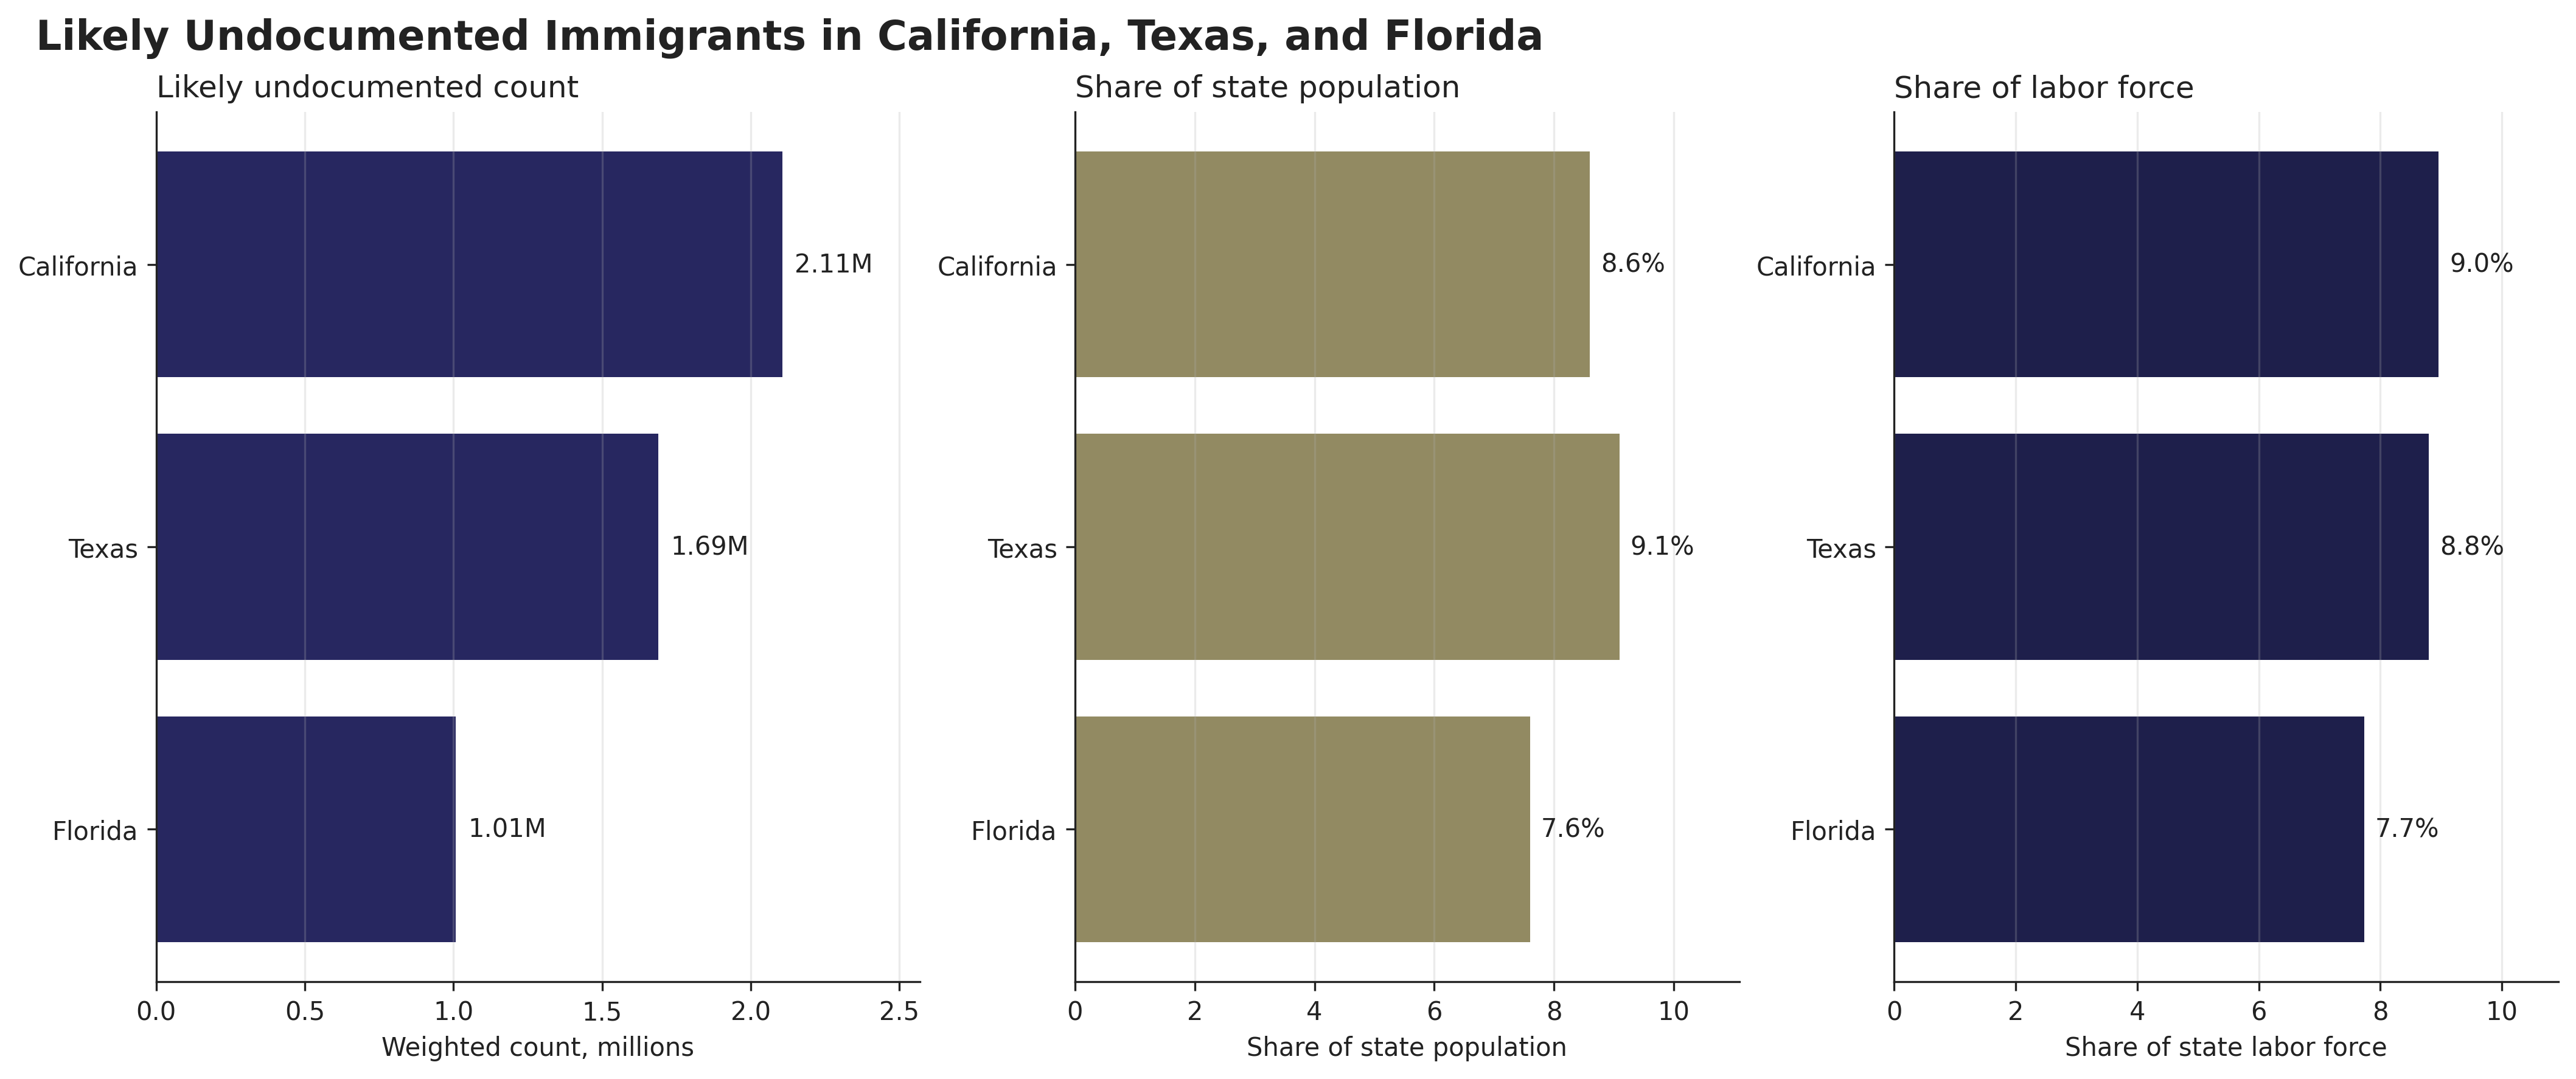

,state,statefip,likely_unauthorized_weighted_count,state_population_weighted,share_of_state_population,share_of_state_population_pct,likely_unauthorized_labor_force_weighted_count,state_labor_force_18_64_weighted,share_of_state_labor_force_18_64,share_of_state_labor_force_18_64_pct
0,California,6,2106422,24496543,0.085989,8.598854,1689903,18860761,0.089599,8.959888
1,Texas,48,1689842,18587379,0.090913,9.091341,1261717,14332284,0.088033,8.803321
2,Florida,12,1007740,13259642,0.076001,7.600054,787371,10176689,0.077370,7.737006


In [19]:
# Figure 1 detail: California, Texas, and Florida undocumented counts and share
import runpy
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Regenerate the figure/table from the reproducible script using notebook dataframes.
runpy.run_path(
    'scripts/figure_state_undocumented_counts_share.py',
    init_globals={
        'VALDOS_COLORS': VALDOS_COLORS,
        'ipums_df': ipums_df,
        'foreign_born_df': foreign_born_df,
        'WEIGHT_COL': WEIGHT_COL,
    },
    run_name='__main__',
)

figure1_detail_png = Path('outputs/figures/ca_tx_fl_likely_unauthorized_counts_share.png')
figure1_detail_csv = Path('outputs/figures/ca_tx_fl_likely_unauthorized_counts_share.csv')

display(Image(filename=str(figure1_detail_png)))
display(pd.read_csv(figure1_detail_csv))


- Demographics

In [20]:
# Likely undocumented / unauthorized population from current notebook rules
if 'PERWT_num' not in foreign_born_df.columns:
    foreign_born_df['PERWT_num'] = pd.to_numeric(foreign_born_df.get('PERWT', 0), errors='coerce').fillna(0)

unauthorized_mask = ~foreign_born_df['likely_legal'].fillna(False).astype(bool)
documented_mask = foreign_born_df['likely_legal'].fillna(False).astype(bool)

# Average age, weighted (likely unauthorized)
undoc_age = pd.to_numeric(foreign_born_df.loc[unauthorized_mask, 'AGE'], errors='coerce')
undoc_wt = foreign_born_df.loc[unauthorized_mask, 'PERWT_num']
total_weight = undoc_wt.sum()
weighted_avg_age = (undoc_age * undoc_wt).sum() / total_weight

print(f"Weighted average age (likely unauthorized): {weighted_avg_age:.1f}")
print(f"Weighted undocumented total: {total_weight:,.0f}")

# Gender shares, weighted (likely unauthorized)
sex_labels = {
    1: 'Male',
    2: 'Female',
}

undoc_sex = pd.to_numeric(foreign_born_df.loc[unauthorized_mask, 'SEX'], errors='coerce').map(sex_labels).fillna('Unknown')
gender_share = (
    pd.DataFrame({'sex_label': undoc_sex, 'PERWT_num': undoc_wt})
    .groupby('sex_label')['PERWT_num']
    .sum()
    .div(total_weight)
    .mul(100)
    .sort_values(ascending=False)
)

print("\nGender share (likely unauthorized):")
print(gender_share.round(1).astype(str) + "%")

def compute_education_share(df, mask, weight_col='PERWT_num'):
    subset_educ = pd.to_numeric(df.loc[mask, 'EDUC'], errors='coerce')
    subset_wt = df.loc[mask, weight_col]

    education_bucket = pd.Series('Unknown / missing', index=subset_educ.index, dtype='object')
    education_bucket.loc[subset_educ.between(1, 5, inclusive='both')] = 'Less than high school'
    education_bucket.loc[subset_educ == 6] = 'High school'
    education_bucket.loc[subset_educ.between(7, 9, inclusive='both')] = 'Some college'
    education_bucket.loc[subset_educ.between(10, 11, inclusive='both')] = "Bachelor's or higher"
    education_bucket.loc[subset_educ == 99] = 'Unknown / missing'

    education_bucket_order = [
        'Less than high school',
        'High school',
        'Some college',
        "Bachelor's or higher",
        'Unknown / missing',
    ]
    education_bucket = pd.Categorical(
        education_bucket,
        categories=education_bucket_order,
        ordered=True
    )

    total = subset_wt.sum()
    education_share = (
        pd.DataFrame({'education_bucket': education_bucket, weight_col: subset_wt})
        .groupby('education_bucket', observed=False)[weight_col]
        .sum()
        .div(total)
        .mul(100)
    )
    return education_share

education_share_unauthorized = compute_education_share(foreign_born_df, unauthorized_mask)
education_share_documented = compute_education_share(foreign_born_df, documented_mask)

print("\nEducation share (likely unauthorized):")
print(education_share_unauthorized.round(1).astype(str) + "%")

print("\nEducation share (likely documented immigrants):")
print(education_share_documented.round(1).astype(str) + "%")

Weighted average age (likely unauthorized): 39.0
Weighted undocumented total: 10,868,591

Gender share (likely unauthorized):
sex_label
Male      55.0%
Female    45.0%
Name: PERWT_num, dtype: object

Education share (likely unauthorized):
education_bucket
Less than high school    22.1%
High school              34.5%
Some college             13.1%
Bachelor's or higher     23.9%
Unknown / missing         6.5%
Name: PERWT_num, dtype: object

Education share (likely documented immigrants):
education_bucket
Less than high school     9.9%
High school              29.0%
Some college             17.3%
Bachelor's or higher     39.5%
Unknown / missing         4.3%
Name: PERWT_num, dtype: object


# QCEW Annual Average Employment by NAICS Sector


Loaded 20 two-digit NAICS sectors from C:\Users\linds\repos\Unidos\data\2024.annual.by_industry.
Saved table to C:\Users\linds\repos\Unidos\outputs\tables\qcew_2024_us_annual_avg_employment_by_naics_sector.csv.
Saved figure to C:\Users\linds\repos\Unidos\outputs\figures\qcew_2024_us_annual_avg_employment_by_naics_sector.png and C:\Users\linds\repos\Unidos\outputs\figures\qcew_2024_us_annual_avg_employment_by_naics_sector.svg.


,naics_code,industry_short_title,annual_avg_employment,annual_avg_employment_millions,ownership_rows_summed
0,11,"Agriculture, forestry, fishing and hunting",1259402,1.26,Federal Government; Local Government; Private;...
1,21,"Mining, quarrying, and oil and gas extraction",587151,0.59,Local Government; Private
2,22,Utilities,856308,0.86,Federal Government; Local Government; Private;...
3,23,Construction,8317572,8.32,Federal Government; Local Government; Private;...
4,31-33,Manufacturing,12784104,12.78,Federal Government; Local Government; Private;...
5,42,Wholesale trade,6107071,6.11,Federal Government; Local Government; Private
6,44-45,Retail trade,15529520,15.53,Federal Government; Local Government; Private;...
7,48-49,Transportation and warehousing,7532742,7.53,Federal Government; Local Government; Private;...
8,51,Information,3044132,3.04,Federal Government; Local Government; Private;...
9,52,Finance and insurance,6327482,6.33,Federal Government; Local Government; Private;...


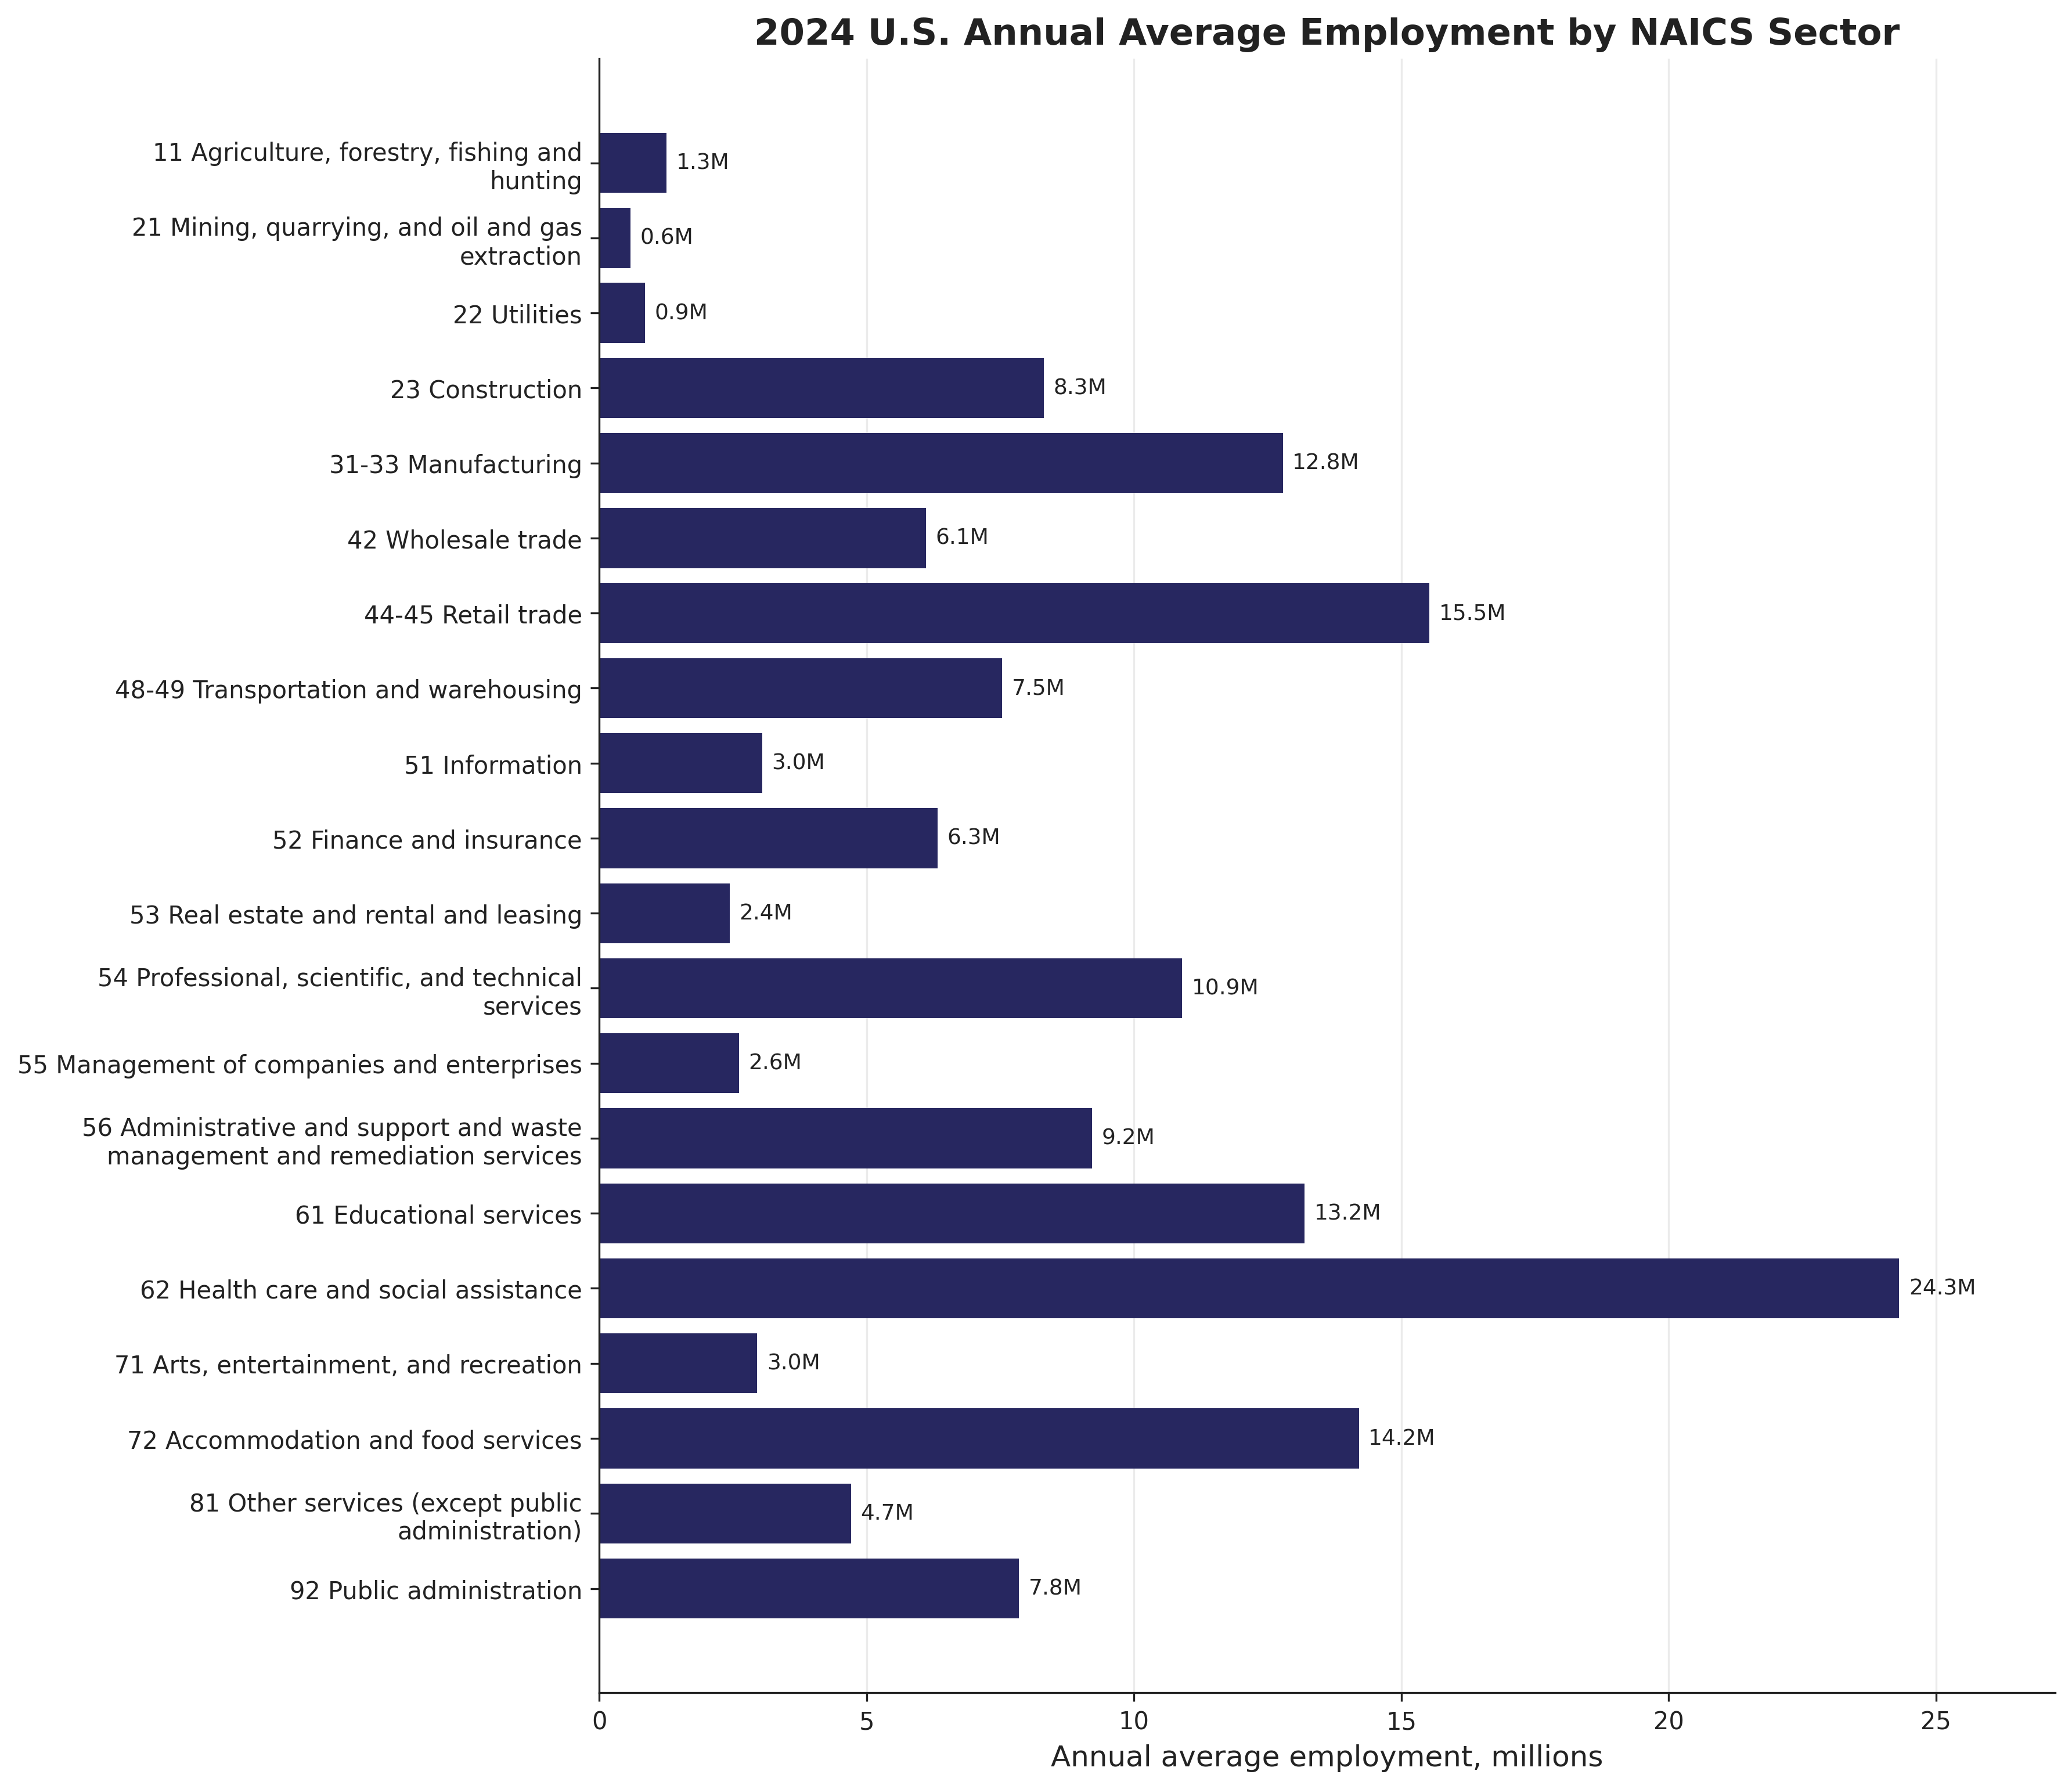

,naics_code,industry_short_title,annual_avg_employment,annual_avg_employment_millions,ownership_rows_summed
0,11,"Agriculture, forestry, fishing and hunting",1259402,1.259402,Federal Government; Local Government; Private;...
1,21,"Mining, quarrying, and oil and gas extraction",587151,0.587151,Local Government; Private
2,22,Utilities,856308,0.856308,Federal Government; Local Government; Private;...
3,23,Construction,8317572,8.317572,Federal Government; Local Government; Private;...
4,31-33,Manufacturing,12784104,12.784104,Federal Government; Local Government; Private;...
5,42,Wholesale trade,6107071,6.107071,Federal Government; Local Government; Private
6,44-45,Retail trade,15529520,15.529520,Federal Government; Local Government; Private;...
7,48-49,Transportation and warehousing,7532742,7.532742,Federal Government; Local Government; Private;...
8,51,Information,3044132,3.044132,Federal Government; Local Government; Private;...
9,52,Finance and insurance,6327482,6.327482,Federal Government; Local Government; Private;...


In [21]:
import runpy
from IPython.display import Image, display

qcew_sector_employment_globals = runpy.run_path(
    "scripts/qcew_annual_employment_by_naics_sector.py",
    init_globals={
        "VALDOS_COLORS": VALDOS_COLORS,
        "display": display,
        "QCEW_SHOW_FIGURE": False,
    },
    run_name="__main__",
)

qcew_us_sector_employment = qcew_sector_employment_globals["qcew_us_sector_employment"]
qcew_sector_employment_png = "outputs/figures/qcew_2024_us_annual_avg_employment_by_naics_sector.png"

display(Image(filename=qcew_sector_employment_png))
display(
    qcew_us_sector_employment[[
        "naics_code",
        "industry_short_title",
        "annual_avg_employment",
        "annual_avg_employment_millions",
        "ownership_rows_summed",
    ]]
)


# Figure 3 

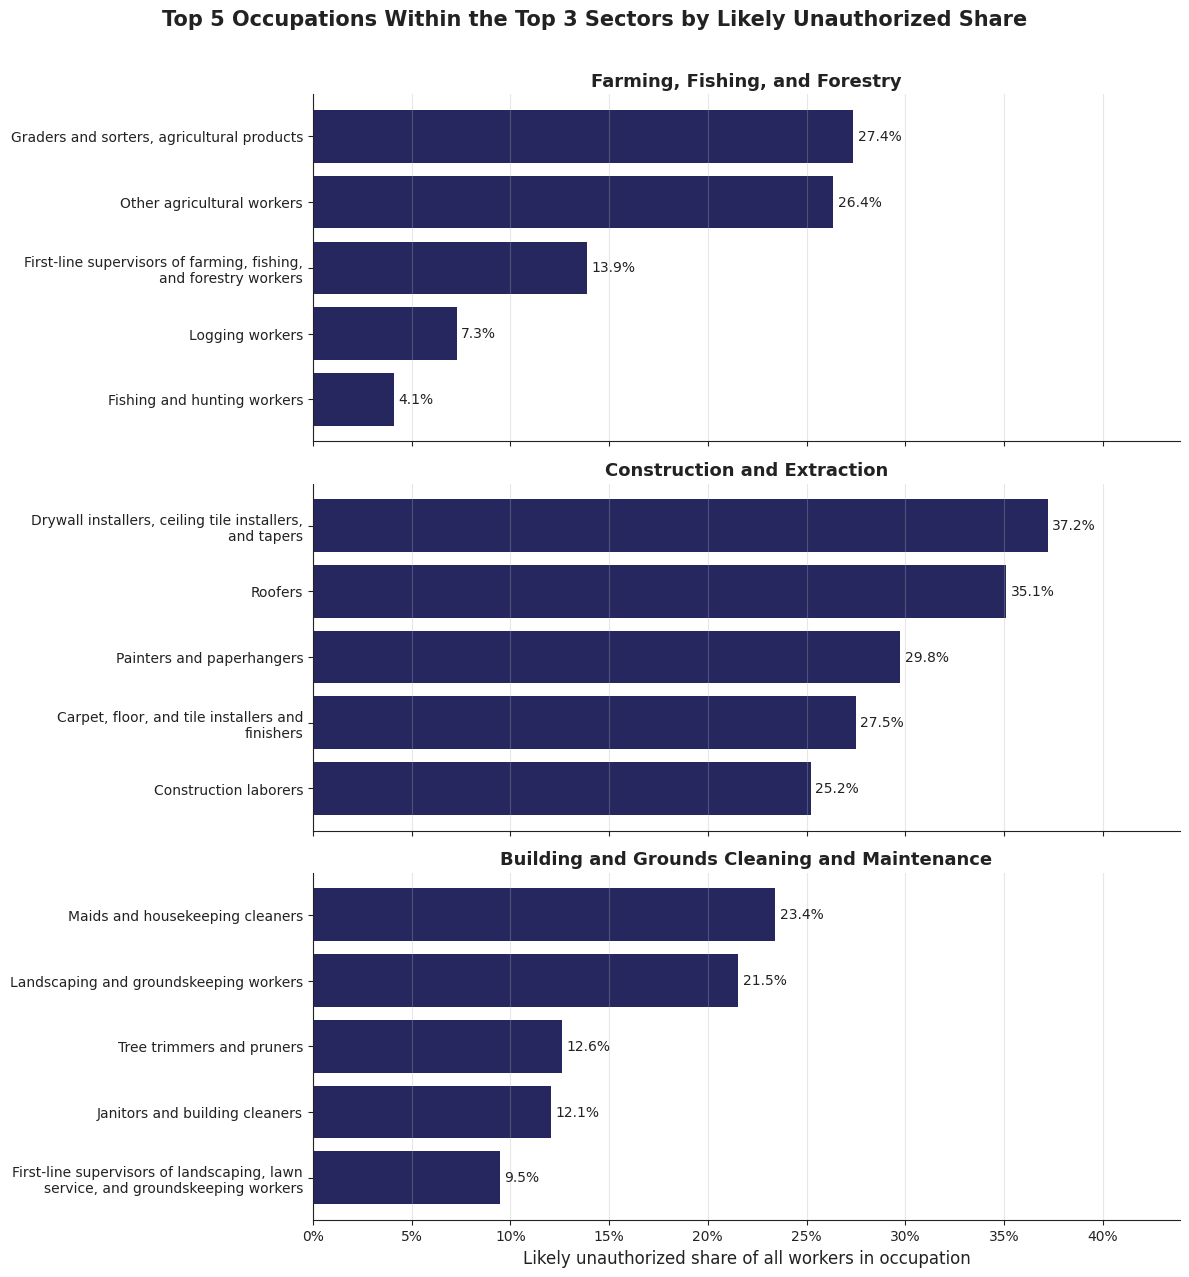

In [22]:
# Figure 3: Top 5 occupations within each of the top 3 sectors
import matplotlib.ticker as mtick
import textwrap

TOP_N_SECTORS = 3
TOP_N_OCCUPATIONS = 5
MIN_SECTOR_WEIGHTED_WORKERS = 100_000
MIN_OCCUPATION_WEIGHTED_WORKERS = 25_000

# Load ACS-to-SOC crosswalk
soc_crosswalk_raw = pd.read_excel(
    r"data/soc_occ_crosswalk.xlsx",
    sheet_name="NEM SOC ACS crosswalk",
    header=4
)

soc_crosswalk = (
    soc_crosswalk_raw
    .rename(columns={
        "ACS code": "acs_occ_code",
        "ACS cccupational title": "occupation_name",
        "National Employment Matrix code": "soc_code",
    })
    .dropna(subset=["acs_occ_code", "soc_code"])
    .copy()
)

soc_crosswalk["acs_occ_code"] = pd.to_numeric(soc_crosswalk["acs_occ_code"], errors="coerce").astype("Int64")
soc_crosswalk["occupation_name"] = soc_crosswalk["occupation_name"].astype(str).str.strip()
soc_crosswalk["soc_2_digit"] = soc_crosswalk["soc_code"].astype(str).str.extract(r"^(\d{2})", expand=False)

soc_major_group_names = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
}

soc_crosswalk["sector_name"] = soc_crosswalk["soc_2_digit"].map(soc_major_group_names)

occ_lookup = (
    soc_crosswalk
    .groupby("acs_occ_code", as_index=True)
    .agg(
        sector_name=("sector_name", "first"),
        occupation_name=("occupation_name", "first"),
    )
)

def add_sector_and_occupation(df):
    occ_source_col = "OCC" if "OCC" in df.columns else "OCC2010"
    out = df.copy()
    out["acs_occ_code"] = pd.to_numeric(out[occ_source_col], errors="coerce").astype("Int64")
    out["sector_name"] = out["acs_occ_code"].map(occ_lookup["sector_name"]).fillna("Unknown")
    out["occupation_name"] = out["acs_occ_code"].map(occ_lookup["occupation_name"]).fillna("Unknown")
    return out

all_workers_df = add_sector_and_occupation(ipums_df)
unauth_workers_df = add_sector_and_occupation(foreign_born_df[~foreign_born_df["likely_legal"]].copy())

if "EMPSTAT" in all_workers_df.columns:
    all_workers_df = all_workers_df[pd.to_numeric(all_workers_df["EMPSTAT"], errors="coerce") == 1].copy()

if "EMPSTAT" in unauth_workers_df.columns:
    unauth_workers_df = unauth_workers_df[pd.to_numeric(unauth_workers_df["EMPSTAT"], errors="coerce") == 1].copy()

all_workers_df = all_workers_df.query("sector_name != 'Unknown' and occupation_name != 'Unknown'")
unauth_workers_df = unauth_workers_df.query("sector_name != 'Unknown' and occupation_name != 'Unknown'")

sector_share = (
    pd.concat([
        weighted_counts(unauth_workers_df, "sector_name").rename("unauth"),
        weighted_counts(all_workers_df, "sector_name").rename("all_workers"),
    ], axis=1)
    .fillna(0)
)

sector_share = sector_share[sector_share["all_workers"] >= MIN_SECTOR_WEIGHTED_WORKERS]
sector_share["share"] = sector_share["unauth"] / sector_share["all_workers"]

top_sectors = sector_share.sort_values("share", ascending=False).head(TOP_N_SECTORS).index.tolist()

occupation_share = (
    pd.concat([
        weighted_counts(
            unauth_workers_df[unauth_workers_df["sector_name"].isin(top_sectors)],
            ["sector_name", "occupation_name"]
        ).rename("unauth"),
        weighted_counts(
            all_workers_df[all_workers_df["sector_name"].isin(top_sectors)],
            ["sector_name", "occupation_name"]
        ).rename("all_workers"),
    ], axis=1)
    .fillna(0)
)

occupation_share = occupation_share[occupation_share["all_workers"] >= MIN_OCCUPATION_WEIGHTED_WORKERS]
occupation_share["share"] = occupation_share["unauth"] / occupation_share["all_workers"]
occupation_share["pct"] = occupation_share["share"] * 100

plot_df = (
    occupation_share
    .reset_index()
    .sort_values(["sector_name", "share"], ascending=[True, False])
    .groupby("sector_name", group_keys=False)
    .head(TOP_N_OCCUPATIONS)
)

fig, axes = plt.subplots(
    nrows=len(top_sectors),
    ncols=1,
    figsize=(12, 4.2 * len(top_sectors)),
    sharex=True
)

if len(top_sectors) == 1:
    axes = [axes]

for ax, sector in zip(axes, top_sectors):
    sector_df = (
        plot_df[plot_df["sector_name"] == sector]
        .sort_values("share", ascending=True)
    )

    labels = [
        "\n".join(textwrap.wrap(name, width=44))
        for name in sector_df["occupation_name"]
    ]

    bars = ax.barh(labels, sector_df["pct"], color=VALDOS_COLORS["primary"])
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in sector_df["pct"]], padding=3)

    ax.set_title(sector, fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

axes[-1].set_xlabel("Likely unauthorized share of all workers in occupation", fontsize=12)
axes[-1].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

max_pct = plot_df["pct"].max()
if pd.notna(max_pct):
    axes[-1].set_xlim(0, max_pct * 1.18)

fig.suptitle(
    "Top 5 Occupations Within the Top 3 Sectors by Likely Unauthorized Share",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


### Capital Input Growth for Undocumented-Immigrant Occupational Sectors

BLS productivity capital input is reported by industry, while the undocumented-immigrant sectors here are occupational groups. These cells link each occupation sector to BLS industries using the ACS industry distribution of likely undocumented workers in that occupation sector, then compute an industry-share-weighted capital input growth series.


In [23]:
# UNDOCUMENTED OCCUPATIONAL SECTORS: capital input YoY growth
from pathlib import Path
from IPython.display import display

TARGET_UNDOCUMENTED_OCCUPATION_SECTORS = {
    "Construction and Extraction": "Construction and Extraction",
    "Farming, Fishing, and Forestry": "Farming, Fishing, and Agriculture",
    "Building and Grounds Cleaning and Maintenance": "Building/Grounds Cleaning and Maintenance",
}
TOP_LINKED_INDUSTRIES_TO_SHOW = 5

productivity_csv_path = Path("data/major-industry-total-factor-productivity-klems.csv")
productivity_xlsx_path = Path("data/major-industry-total-factor-productivity-klems.xlsx")

if productivity_csv_path.exists():
    productivity_raw = pd.read_csv(productivity_csv_path)
    productivity_source = productivity_csv_path
elif productivity_xlsx_path.exists():
    productivity_raw = pd.read_excel(productivity_xlsx_path, sheet_name="MachineReadable")
    productivity_source = productivity_xlsx_path
else:
    raise FileNotFoundError("Expected major-industry-total-factor-productivity-klems.csv or .xlsx in data/.")

productivity_raw = productivity_raw.copy()
for col in ["NAICS", "Industry", "Basis", "Measure", "Units"]:
    productivity_raw[col] = productivity_raw[col].astype(str).str.strip()

def get_capital_input_series(units, value_col):
    out = productivity_raw[
        (productivity_raw["Measure"] == "Capital input")
        & (productivity_raw["Basis"] == "All workers")
        & (productivity_raw["Units"] == units)
    ].copy()
    out["Year"] = pd.to_numeric(out["Year"], errors="coerce")
    out[value_col] = pd.to_numeric(out["Value"], errors="coerce")
    out = out.dropna(subset=["Year"])
    out["Year"] = out["Year"].astype(int)
    return out[["NAICS", "Industry", "Year", value_col]]

capital_input_index = get_capital_input_series(
    "Index (2017=100)",
    "capital_input_index_2017_100",
).dropna(subset=["capital_input_index_2017_100"])
capital_input_yoy = get_capital_input_series(
    "% Change from previous year",
    "capital_input_yoy_pct_change",
)

capital_input = (
    capital_input_index
    .merge(capital_input_yoy, on=["NAICS", "Industry", "Year"], how="left")
    .rename(columns={"NAICS": "bls_major_naics", "Industry": "bls_major_industry"})
    .sort_values(["bls_major_naics", "Year"])
)

if capital_input["capital_input_yoy_pct_change"].notna().sum() == 0:
    capital_input["capital_input_yoy_pct_change"] = (
        capital_input
        .groupby("bls_major_naics")["capital_input_index_2017_100"]
        .pct_change()
        .mul(100)
    )

# ACS INDNAICS is more detailed than the BLS major-industry productivity series.
# This map rolls ACS industries up to comparable BLS major-industry NAICS groups.
acs_to_bls_major_naics = {
    "11": "11",
    "21": "21",
    "22": "22",
    "23": "23",
    "31": "MN",
    "32": "MN",
    "33": "MN",
    "42": "42,44-45",
    "44": "42,44-45",
    "45": "42,44-45",
    "48": "48-49",
    "49": "48-49",
    "51": "51",
    "52": "52-53",
    "53": "52-53",
    "54": "54-56",
    "55": "54-56",
    "56": "54-56",
    "61": "61-62",
    "62": "61-62",
    "71": "71-72",
    "72": "71-72",
    "81": "81",
}

major_productivity_codes = set(acs_to_bls_major_naics.values())
bls_major_industry_lookup = (
    capital_input[capital_input["bls_major_naics"].isin(major_productivity_codes)]
    [["bls_major_naics", "bls_major_industry"]]
    .drop_duplicates()
    .set_index("bls_major_naics")["bls_major_industry"]
)

undoc_occ_sector_workers = unauth_workers_df[
    unauth_workers_df["sector_name"].isin(TARGET_UNDOCUMENTED_OCCUPATION_SECTORS)
].copy()

if WEIGHT_COL not in undoc_occ_sector_workers.columns:
    undoc_occ_sector_workers[WEIGHT_COL] = pd.to_numeric(
        undoc_occ_sector_workers.get("PERWT", 0),
        errors="coerce",
    ).fillna(0)

undoc_occ_sector_workers["occupation_sector"] = undoc_occ_sector_workers["sector_name"].map(
    TARGET_UNDOCUMENTED_OCCUPATION_SECTORS
)
undoc_occ_sector_workers["sector_order"] = undoc_occ_sector_workers["sector_name"].map(
    {sector: order for order, sector in enumerate(TARGET_UNDOCUMENTED_OCCUPATION_SECTORS, start=1)}
)
undoc_occ_sector_workers["indnaics_clean"] = undoc_occ_sector_workers["INDNAICS"].astype("string").str.strip()
undoc_occ_sector_workers["indnaics_2_digit"] = undoc_occ_sector_workers["indnaics_clean"].str.extract(r"^(\d{2})", expand=False)
undoc_occ_sector_workers["bls_major_naics"] = undoc_occ_sector_workers["indnaics_2_digit"].map(acs_to_bls_major_naics)
undoc_occ_sector_workers["bls_major_industry"] = undoc_occ_sector_workers["bls_major_naics"].map(bls_major_industry_lookup)

sector_worker_totals = (
    undoc_occ_sector_workers
    .groupby(["sector_order", "sector_name", "occupation_sector"], dropna=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="undocumented_workers_in_occ_sector")
)

mapped_occ_sector_workers = undoc_occ_sector_workers.dropna(subset=["bls_major_naics", "bls_major_industry"]).copy()

sector_industry_weights = (
    mapped_occ_sector_workers
    .groupby([
        "sector_order",
        "sector_name",
        "occupation_sector",
        "bls_major_naics",
        "bls_major_industry",
    ], dropna=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="undocumented_workers_in_linked_industry")
    .merge(sector_worker_totals, on=["sector_order", "sector_name", "occupation_sector"], how="left")
)

sector_mapped_totals = (
    sector_industry_weights
    .groupby(["sector_order", "sector_name", "occupation_sector"], dropna=False)["undocumented_workers_in_linked_industry"]
    .sum()
    .reset_index(name="mapped_undocumented_workers")
)
sector_industry_weights = sector_industry_weights.merge(
    sector_mapped_totals,
    on=["sector_order", "sector_name", "occupation_sector"],
    how="left",
)
sector_industry_weights["industry_share_within_occ_sector"] = (
    sector_industry_weights["undocumented_workers_in_linked_industry"]
    / sector_industry_weights["mapped_undocumented_workers"]
)
sector_industry_weights["mapped_share_of_sector_workers"] = (
    sector_industry_weights["mapped_undocumented_workers"]
    / sector_industry_weights["undocumented_workers_in_occ_sector"]
    * 100
)

missing_target_sectors = set(TARGET_UNDOCUMENTED_OCCUPATION_SECTORS) - set(sector_worker_totals["sector_name"])
if missing_target_sectors:
    raise ValueError(f"Missing target occupation sectors in ACS/SOC mapping: {sorted(missing_target_sectors)}")
if sector_industry_weights.empty:
    raise ValueError("No target occupation-sector workers could be linked to BLS productivity industries.")

linked_capital_input = sector_industry_weights.merge(
    capital_input,
    on=["bls_major_naics", "bls_major_industry"],
    how="inner",
)

capital_input_records = []
for keys, group in linked_capital_input.groupby(["sector_order", "sector_name", "occupation_sector", "Year"], sort=True):
    sector_order, sector_name, occupation_sector, year = keys
    yoy_valid = group["capital_input_yoy_pct_change"].notna()
    index_valid = group["capital_input_index_2017_100"].notna()
    capital_input_records.append({
        "sector_order": sector_order,
        "sector_name": sector_name,
        "occupation_sector": occupation_sector,
        "Year": year,
        "undocumented_workers_in_occ_sector": group["undocumented_workers_in_occ_sector"].iloc[0],
        "mapped_undocumented_workers": group["mapped_undocumented_workers"].iloc[0],
        "mapped_share_of_sector_workers": group["mapped_share_of_sector_workers"].iloc[0],
        "linked_bls_industry_count": group["bls_major_naics"].nunique(),
        "weighted_capital_input_index_2017_100": (
            (group.loc[index_valid, "capital_input_index_2017_100"] * group.loc[index_valid, "industry_share_within_occ_sector"]).sum()
            / group.loc[index_valid, "industry_share_within_occ_sector"].sum()
            if index_valid.any() else pd.NA
        ),
        "weighted_capital_input_yoy_pct_change": (
            (group.loc[yoy_valid, "capital_input_yoy_pct_change"] * group.loc[yoy_valid, "industry_share_within_occ_sector"]).sum()
            / group.loc[yoy_valid, "industry_share_within_occ_sector"].sum()
            if yoy_valid.any() else pd.NA
        ),
    })

capital_input_yoy_undoc_occ_sectors = (
    pd.DataFrame(capital_input_records)
    .sort_values(["sector_order", "Year"])
    .reset_index(drop=True)
)

for numeric_col in ["weighted_capital_input_index_2017_100", "weighted_capital_input_yoy_pct_change"]:
    capital_input_yoy_undoc_occ_sectors[numeric_col] = pd.to_numeric(
        capital_input_yoy_undoc_occ_sectors[numeric_col],
        errors="coerce",
    )

capital_input_yoy_undoc_occ_sectors_csv = Path("outputs/tables/capital_input_yoy_undocumented_occupation_sectors.csv")
capital_input_yoy_undoc_occ_sectors_csv.parent.mkdir(parents=True, exist_ok=True)
capital_input_yoy_undoc_occ_sectors.to_csv(capital_input_yoy_undoc_occ_sectors_csv, index=False)

sector_summary = (
    sector_worker_totals
    .merge(sector_mapped_totals, on=["sector_order", "sector_name", "occupation_sector"], how="left")
    .fillna({"mapped_undocumented_workers": 0})
)
sector_summary["mapped_share_of_sector_workers"] = (
    sector_summary["mapped_undocumented_workers"] / sector_summary["undocumented_workers_in_occ_sector"] * 100
)
sector_summary["share_of_selected_undoc_occ_workers"] = (
    sector_summary["undocumented_workers_in_occ_sector"] / sector_summary["undocumented_workers_in_occ_sector"].sum() * 100
)

sector_industry_weights_display = (
    sector_industry_weights
    .sort_values(["sector_order", "industry_share_within_occ_sector"], ascending=[True, False])
    .groupby("occupation_sector", group_keys=False)
    .head(TOP_LINKED_INDUSTRIES_TO_SHOW)
    .assign(
        undocumented_workers_in_linked_industry=lambda df: df["undocumented_workers_in_linked_industry"].round(0).astype(int),
        industry_share_within_occ_sector=lambda df: (df["industry_share_within_occ_sector"] * 100).round(1),
    )
    [[
        "occupation_sector",
        "bls_major_naics",
        "bls_major_industry",
        "undocumented_workers_in_linked_industry",
        "industry_share_within_occ_sector",
    ]]
)

print(f"Loaded productivity data from {productivity_source}")
print(f"Saved weighted YoY capital input table to {capital_input_yoy_undoc_occ_sectors_csv}")

print("Selected likely undocumented occupation sectors:")
display(
    sector_summary
    .sort_values("sector_order")
    .assign(
        undocumented_workers_in_occ_sector=lambda df: df["undocumented_workers_in_occ_sector"].round(0).astype(int),
        mapped_undocumented_workers=lambda df: df["mapped_undocumented_workers"].round(0).astype(int),
        mapped_share_of_sector_workers=lambda df: df["mapped_share_of_sector_workers"].round(1),
        share_of_selected_undoc_occ_workers=lambda df: df["share_of_selected_undoc_occ_workers"].round(1),
    )
    [[
        "occupation_sector",
        "undocumented_workers_in_occ_sector",
        "mapped_undocumented_workers",
        "mapped_share_of_sector_workers",
        "share_of_selected_undoc_occ_workers",
    ]]
)

print("Top linked BLS industries within each occupation sector:")
display(sector_industry_weights_display)


Loaded productivity data from data\major-industry-total-factor-productivity-klems.xlsx
Saved weighted YoY capital input table to outputs\tables\capital_input_yoy_undocumented_occupation_sectors.csv
Selected likely undocumented occupation sectors:


,occupation_sector,undocumented_workers_in_occ_sector,mapped_undocumented_workers,mapped_share_of_sector_workers,share_of_selected_undoc_occ_workers
0,Construction and Extraction,1280509,1277964,99.8,56.3
1,"Farming, Fishing, and Agriculture",196674,196262,99.8,8.7
2,Building/Grounds Cleaning and Maintenance,795989,790686,99.3,35.0


Top linked BLS industries within each occupation sector:


,occupation_sector,bls_major_naics,bls_major_industry,undocumented_workers_in_linked_industry,industry_share_within_occ_sector
3,Construction and Extraction,23,Construction,1211036,94.8
12,Construction and Extraction,MN,Manufacturing sector,18818,1.5
8,Construction and Extraction,54-56,Professional and business services,10564,0.8
1,Construction and Extraction,21,Mining,10190,0.8
4,Construction and Extraction,"42,44-45",Trade,7520,0.6
13,"Farming, Fishing, and Agriculture",11,"Agriculture, forestry, fishing, and hunting",181732,92.6
17,"Farming, Fishing, and Agriculture","42,44-45",Trade,7813,4.0
24,"Farming, Fishing, and Agriculture",MN,Manufacturing sector,2641,1.3
20,"Farming, Fishing, and Agriculture",54-56,Professional and business services,1542,0.8
16,"Farming, Fishing, and Agriculture",23,Construction,772,0.4


In [24]:
# Recent weighted capital input YoY percent changes for the selected undocumented occupation sectors
recent_year_cutoff = capital_input_yoy_undoc_occ_sectors["Year"].max() - 9
capital_input_yoy_recent = capital_input_yoy_undoc_occ_sectors[
    capital_input_yoy_undoc_occ_sectors["Year"] >= recent_year_cutoff
].copy()

capital_input_yoy_recent_display = capital_input_yoy_recent.assign(
    undocumented_workers_in_occ_sector=lambda df: df["undocumented_workers_in_occ_sector"].round(0).astype(int),
    mapped_undocumented_workers=lambda df: df["mapped_undocumented_workers"].round(0).astype(int),
    mapped_share_of_sector_workers=lambda df: df["mapped_share_of_sector_workers"].round(1),
    weighted_capital_input_index_2017_100=lambda df: df["weighted_capital_input_index_2017_100"].round(2),
    weighted_capital_input_yoy_pct_change=lambda df: df["weighted_capital_input_yoy_pct_change"].round(2),
)[[
    "occupation_sector",
    "Year",
    "weighted_capital_input_yoy_pct_change",
    "weighted_capital_input_index_2017_100",
    "undocumented_workers_in_occ_sector",
    "mapped_share_of_sector_workers",
    "linked_bls_industry_count",
]]

display(capital_input_yoy_recent_display)


,occupation_sector,Year,weighted_capital_input_yoy_pct_change,weighted_capital_input_index_2017_100,undocumented_workers_in_occ_sector,mapped_share_of_sector_workers,linked_bls_industry_count
28,Construction and Extraction,2015,3.33,95.92,1280509,99.8,13
29,Construction and Extraction,2016,4.64,100.39,1280509,99.8,13
30,Construction and Extraction,2017,-0.39,100.00,1280509,99.8,13
31,Construction and Extraction,2018,1.81,101.80,1280509,99.8,13
32,Construction and Extraction,2019,0.83,102.67,1280509,99.8,13
33,Construction and Extraction,2020,4.72,107.53,1280509,99.8,13
34,Construction and Extraction,2021,0.29,107.89,1280509,99.8,13
35,Construction and Extraction,2022,-2.07,105.63,1280509,99.8,13
36,Construction and Extraction,2023,2.77,108.55,1280509,99.8,13
37,Construction and Extraction,2024,3.53,112.35,1280509,99.8,13


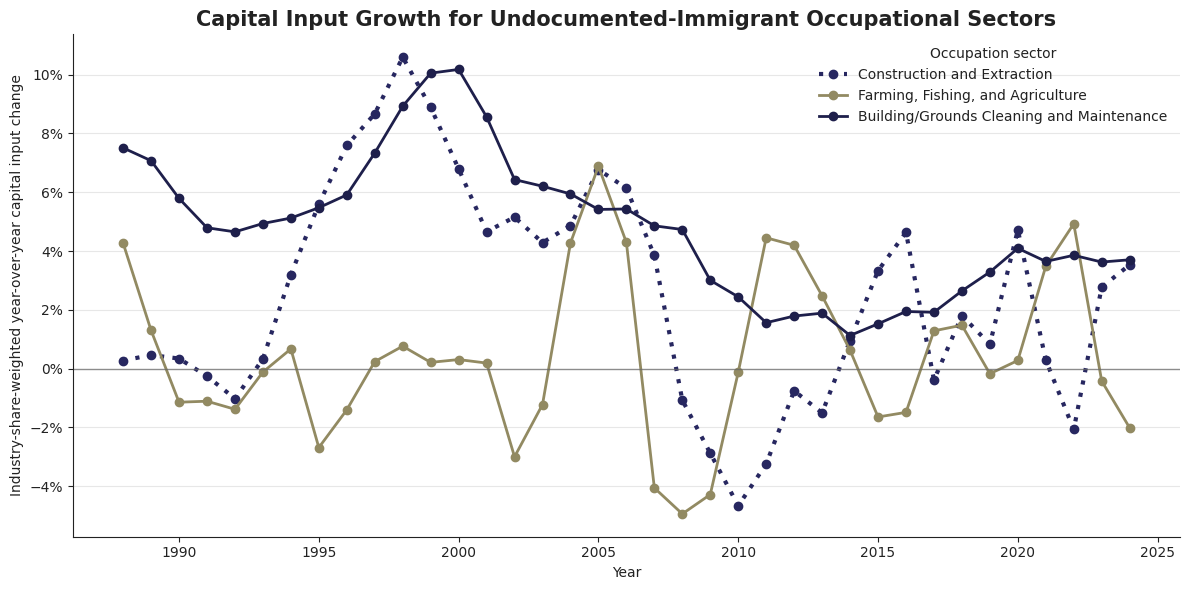

In [25]:
# Plot weighted YoY capital input growth for the selected undocumented occupation sectors
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12, 6))

for occupation_sector, sector_df in capital_input_yoy_undoc_occ_sectors.groupby("occupation_sector", sort=False):
    sector_df = sector_df.dropna(subset=["weighted_capital_input_yoy_pct_change"])
    is_construction = occupation_sector == "Construction and Extraction"
    ax.plot(
        sector_df["Year"],
        sector_df["weighted_capital_input_yoy_pct_change"],
        marker="o",
        linestyle=(0, (1, 2)) if is_construction else "-",
        linewidth=3 if is_construction else 2,
        label=occupation_sector,
    )

ax.axhline(0, color=VALDOS_COLORS["muted_text"], linewidth=1, alpha=0.7)
ax.set_title(
    "Capital Input Growth for Undocumented-Immigrant Occupational Sectors",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Year")
ax.set_ylabel("Industry-share-weighted year-over-year capital input change")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Occupation sector", frameon=False)

plt.tight_layout()
plt.show()


### ALM Task Automation Index Distributions by Worker Status

Map the `occ1990dd_task_alm.dta` task indexes to ACS workers through `OCC1990`, then compare weighted score distributions for documented immigrants, undocumented immigrants, and native-born workers.


Using ACS OCC1990 as the key to occ1990dd_task_alm.dta. Verify this is the intended occ1990dd-compatible occupation code.
Loaded 330 ALM occupation task-score rows from data\occ1990dd_task_alm.dta.


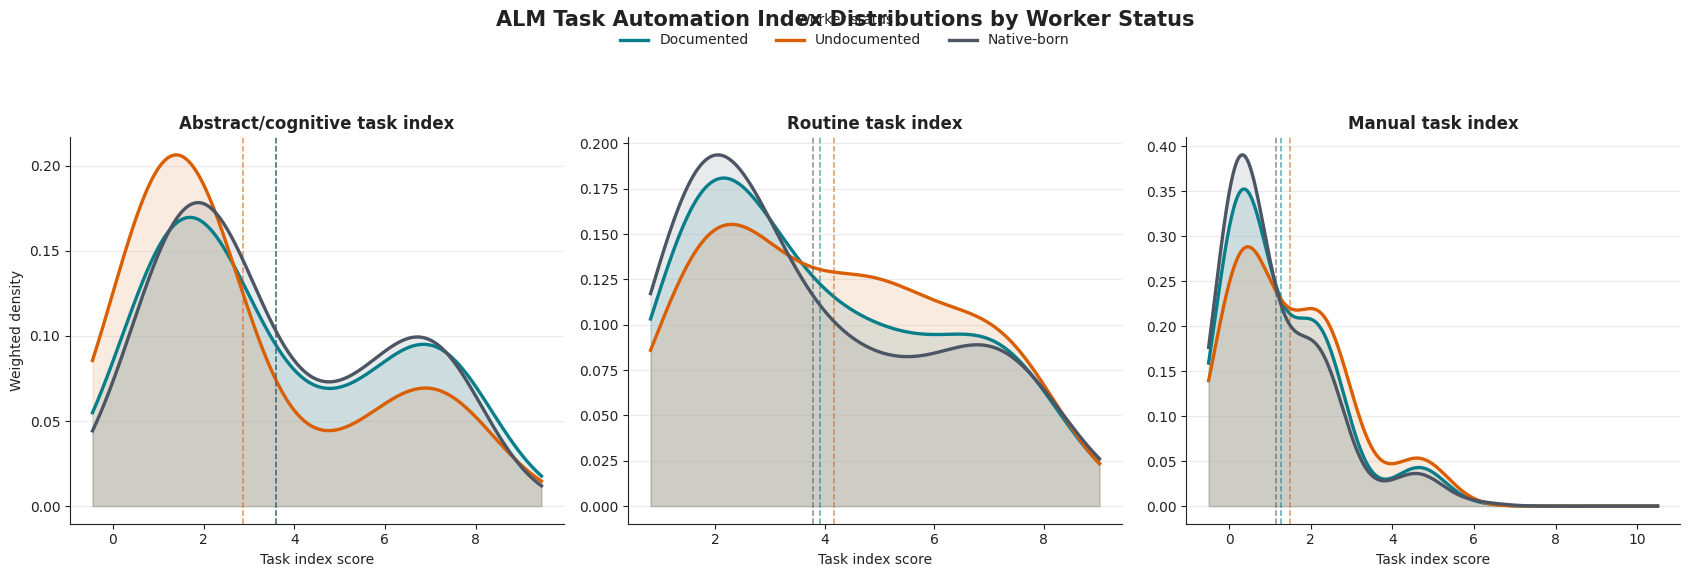

Saved ALM task distribution figure to outputs\figures\alm_task_kde_by_worker_status.png and outputs\figures\alm_task_kde_by_worker_status.svg.
Saved ALM task score summary to outputs\tables\alm_task_scores_by_worker_status_summary.csv.


,worker_status,task_index,task_index_label,unweighted_workers_with_score,weighted_workers,weighted_workers_with_score,score_coverage_pct,weighted_mean_score
0,Documented,task_abstract,Abstract/cognitive task index,816949,20706950,19669497,95.0,3.59
1,Documented,task_routine,Routine task index,816949,20706950,19669497,95.0,3.92
2,Documented,task_manual,Manual task index,816949,20706950,19669497,95.0,1.28
3,Undocumented,task_abstract,Abstract/cognitive task index,267848,8097205,7556086,93.3,2.87
4,Undocumented,task_routine,Routine task index,267848,8097205,7556086,93.3,4.16
5,Undocumented,task_manual,Manual task index,267848,8097205,7556086,93.3,1.50
6,Native-born,task_abstract,Abstract/cognitive task index,5292305,121211585,114721238,94.6,3.61
7,Native-born,task_routine,Routine task index,5292305,121211585,114721238,94.6,3.79
8,Native-born,task_manual,Manual task index,5292305,121211585,114721238,94.6,1.15


In [26]:
# ALM task automation score distributions by worker status
from pathlib import Path
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt

ALM_TASK_PATH = Path("data/occ1990dd_task_alm.dta")
ALM_FIGURE_DIR = Path("outputs/figures")
ALM_TABLE_DIR = Path("outputs/tables")
ALM_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ALM_TABLE_DIR.mkdir(parents=True, exist_ok=True)

TASK_SCORE_COLUMNS = {
    "task_abstract": "Abstract/cognitive task index",
    "task_routine": "Routine task index",
    "task_manual": "Manual task index",
}

if "OCC1990" not in ipums_df.columns:
    raise KeyError(
        "Need OCC1990 in ipums_df to map occ1990dd_task_alm.dta task scores."
    )

if "likely_legal" not in foreign_born_df.columns:
    raise RuntimeError("Run the likely-legal classification cells before this section.")

if WEIGHT_COL not in ipums_df.columns:
    ipums_df[WEIGHT_COL] = pd.to_numeric(ipums_df.get("PERWT", 0), errors="coerce").fillna(0)
if WEIGHT_COL not in foreign_born_df.columns:
    foreign_born_df[WEIGHT_COL] = pd.to_numeric(
        foreign_born_df.get("PERWT", 0),
        errors="coerce",
    ).fillna(0)

alm_task_scores = pd.read_stata(ALM_TASK_PATH)
alm_task_scores = alm_task_scores.rename(columns={"occ1990dd": "alm_occ1990dd"}).copy()
alm_task_scores["alm_occ1990dd"] = pd.to_numeric(
    alm_task_scores["alm_occ1990dd"],
    errors="coerce",
).astype("Int64")
for score_col in TASK_SCORE_COLUMNS:
    alm_task_scores[score_col] = pd.to_numeric(alm_task_scores[score_col], errors="coerce")

alm_task_lookup = (
    alm_task_scores
    .dropna(subset=["alm_occ1990dd"])
    .groupby("alm_occ1990dd", as_index=True)[list(TASK_SCORE_COLUMNS)]
    .mean()
)

print(
    "Using ACS OCC1990 as the key to occ1990dd_task_alm.dta. "
    "Verify this is the intended occ1990dd-compatible occupation code."
)
print(f"Loaded {len(alm_task_lookup):,} ALM occupation task-score rows from {ALM_TASK_PATH}.")

def attach_alm_scores(df):
    out = df.copy()
    out["alm_occ1990dd"] = pd.to_numeric(out["OCC1990"], errors="coerce").astype("Int64")
    for score_col in TASK_SCORE_COLUMNS:
        out[score_col] = out["alm_occ1990dd"].map(alm_task_lookup[score_col])
    return out

def employed_workers(df):
    out = df.copy()
    out[WEIGHT_COL] = pd.to_numeric(out[WEIGHT_COL], errors="coerce").fillna(0)
    if "EMPSTAT" in out.columns:
        out = out[pd.to_numeric(out["EMPSTAT"], errors="coerce") == 1].copy()
    return out[out[WEIGHT_COL] > 0].copy()

def weighted_gaussian_kde(score_weights, grid):
    values = score_weights.index.to_numpy(dtype=float)
    weights = score_weights.to_numpy(dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]

    if len(values) < 2 or weights.sum() <= 0:
        return np.full_like(grid, np.nan, dtype=float)

    weight_sum = weights.sum()
    weighted_mean = np.average(values, weights=weights)
    weighted_var = np.average((values - weighted_mean) ** 2, weights=weights)
    weighted_sd = np.sqrt(weighted_var)
    if not np.isfinite(weighted_sd) or weighted_sd <= 0:
        return np.full_like(grid, np.nan, dtype=float)

    effective_n = weight_sum ** 2 / np.square(weights).sum()
    bandwidth = 1.06 * weighted_sd * effective_n ** (-1 / 5)
    if not np.isfinite(bandwidth) or bandwidth <= 0:
        bandwidth = weighted_sd * 0.25

    z = (grid[:, None] - values[None, :]) / bandwidth
    density = np.exp(-0.5 * z**2) @ weights
    density = density / (weight_sum * bandwidth * np.sqrt(2 * np.pi))
    return density

native_born_df = ipums_df[pd.to_numeric(ipums_df["BPL"], errors="coerce") < 150].copy()
documented_immigrant_df = foreign_born_df[
    foreign_born_df["likely_legal"].fillna(False).astype(bool)
].copy()
undocumented_immigrant_df = foreign_born_df[
    ~foreign_born_df["likely_legal"].fillna(False).astype(bool)
].copy()

worker_status_groups = {
    "Documented": attach_alm_scores(documented_immigrant_df),
    "Undocumented": attach_alm_scores(undocumented_immigrant_df),
    "Native-born": attach_alm_scores(native_born_df),
}

status_colors = {
    "Documented": "#087E8B",
    "Undocumented": "#D95F02",
    "Native-born": "#4B5563",
}

score_distributions = {score_col: {} for score_col in TASK_SCORE_COLUMNS}
summary_rows = []

for status_label, status_df in worker_status_groups.items():
    workers = employed_workers(status_df)
    weighted_workers = workers[WEIGHT_COL].sum()

    for score_col, score_label in TASK_SCORE_COLUMNS.items():
        workers_with_scores = workers[workers[score_col].notna()].copy()
        score_weights = (
            workers_with_scores
            .groupby(score_col, dropna=True)[WEIGHT_COL]
            .sum()
            .sort_index()
        )
        score_distributions[score_col][status_label] = score_weights

        weighted_workers_with_scores = workers_with_scores[WEIGHT_COL].sum()
        weighted_mean_score = (
            np.average(
                score_weights.index.to_numpy(dtype=float),
                weights=score_weights.to_numpy(dtype=float),
            )
            if len(score_weights) > 0 and weighted_workers_with_scores > 0
            else np.nan
        )

        summary_rows.append({
            "worker_status": status_label,
            "task_index": score_col,
            "task_index_label": score_label,
            "unweighted_workers_with_score": len(workers_with_scores),
            "weighted_workers": weighted_workers,
            "weighted_workers_with_score": weighted_workers_with_scores,
            "score_coverage_pct": (
                weighted_workers_with_scores / weighted_workers * 100
                if weighted_workers
                else np.nan
            ),
            "weighted_mean_score": weighted_mean_score,
        })

alm_task_status_summary = pd.DataFrame(summary_rows)
alm_task_status_summary_csv = ALM_TABLE_DIR / "alm_task_scores_by_worker_status_summary.csv"
alm_task_status_summary.to_csv(alm_task_status_summary_csv, index=False)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(TASK_SCORE_COLUMNS),
    figsize=(17, 5.5),
    sharey=False,
)

for ax, (score_col, score_label) in zip(axes, TASK_SCORE_COLUMNS.items()):
    score_value_arrays = [
        weights.index.to_numpy(dtype=float)
        for weights in score_distributions[score_col].values()
        if len(weights) > 0
    ]
    if not score_value_arrays:
        ax.set_title(score_label, fontsize=12, fontweight="bold")
        ax.text(0.5, 0.5, "No mapped scores", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    all_score_values = np.concatenate(score_value_arrays)
    x_min = np.nanmin(all_score_values)
    x_max = np.nanmax(all_score_values)
    x_padding = max((x_max - x_min) * 0.05, 0.10)
    x_grid = np.linspace(x_min - x_padding, x_max + x_padding, 500)

    for status_label, score_weights in score_distributions[score_col].items():
        if len(score_weights) == 0:
            continue

        density = weighted_gaussian_kde(score_weights, x_grid)
        color = status_colors[status_label]
        ax.plot(x_grid, density, label=status_label, color=color, linewidth=2.4)
        ax.fill_between(x_grid, density, color=color, alpha=0.12)

        mean_score = np.average(
            score_weights.index.to_numpy(dtype=float),
            weights=score_weights.to_numpy(dtype=float),
        )
        ax.axvline(mean_score, color=color, linestyle="--", linewidth=1.1, alpha=0.65)

    ax.set_title(score_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Task index score")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Weighted density")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Worker status", frameon=False, loc="upper center", ncol=3)
fig.suptitle(
    "ALM Task Automation Index Distributions by Worker Status",
    fontsize=15,
    fontweight="bold",
    y=1.04,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])

alm_task_kde_png = ALM_FIGURE_DIR / "alm_task_kde_by_worker_status.png"
alm_task_kde_svg = ALM_FIGURE_DIR / "alm_task_kde_by_worker_status.svg"
fig.savefig(alm_task_kde_png, dpi=300, bbox_inches="tight")
fig.savefig(alm_task_kde_svg, bbox_inches="tight")
plt.show()

print(f"Saved ALM task distribution figure to {alm_task_kde_png} and {alm_task_kde_svg}.")
print(f"Saved ALM task score summary to {alm_task_status_summary_csv}.")
display(
    alm_task_status_summary.assign(
        weighted_workers=lambda df: df["weighted_workers"].round(0).astype(int),
        weighted_workers_with_score=lambda df: df["weighted_workers_with_score"].round(0).astype(int),
        score_coverage_pct=lambda df: df["score_coverage_pct"].round(1),
        weighted_mean_score=lambda df: df["weighted_mean_score"].round(2),
    )
)


- Impute median wages

### Median Wages by Status


In [27]:
import runpy
from IPython.display import display

status_median_wage_globals = runpy.run_path(
    "scripts/status_split_median_wages.py",
    init_globals={
        "ipums_df": ipums_df,
        "foreign_born_df": foreign_born_df,
        "WEIGHT_COL": WEIGHT_COL,
        "WRITE_OUTPUT_CSV": True,
    },
    run_name="__main__",
)

display(status_median_wage_globals["status_median_wages"])
print(status_median_wage_globals["status_median_wages_csv"])


Selected median annual wages for native born, documented, and undocumented workers in FL, TX, CA, and nationally (UHRSWORK >= 35 hours/week, WKSWORK1 >= 50 weeks worked):
Filtered to 4,756,488 unweighted matching records across all statuses.
Saved table to outputs\tables\selected_median_wages_by_status_fl_tx_ca_nat.csv
      status geography  statefip  acs_occ_code                                         occupation_name weighted_median_annual_wage weighted_workers_with_wage unweighted_workers_with_wage
 Native born  National         0          4230                         Maids and housekeeping cleaners                     $28,964                    249,319                       10,250
 Native born  National         0          6040              Graders and sorters, agricultural products                     $34,299                     11,669                          530
 Native born  National         0          6330 Drywall installers, ceiling tile installers, and tapers                

,status,geography,statefip,acs_occ_code,occupation_name,weighted_median_annual_wage,weighted_workers_with_wage,unweighted_workers_with_wage
0,Native born,National,0,4230,Maids and housekeeping cleaners,28964.0,249319.0,10250
1,Native born,National,0,6040,"Graders and sorters, agricultural products",34299.0,11669.0,530
2,Native born,National,0,6330,"Drywall installers, ceiling tile installers, a...",48582.0,29399.0,1212
3,Native born,FL,12,4230,Maids and housekeeping cleaners,29200.0,17278.0,562
4,Native born,FL,12,6040,"Graders and sorters, agricultural products",31092.0,103.0,5
5,Native born,FL,12,6330,"Drywall installers, ceiling tile installers, a...",40000.0,1674.0,61
6,Native born,TX,48,4230,Maids and housekeeping cleaners,25000.0,19835.0,740
7,Native born,TX,48,6040,"Graders and sorters, agricultural products",24214.0,557.0,21
8,Native born,TX,48,6330,"Drywall installers, ceiling tile installers, a...",33598.0,2570.0,83
9,Native born,CA,6,4230,Maids and housekeeping cleaners,33227.0,16080.0,640


outputs\tables\selected_median_wages_by_status_fl_tx_ca_nat.csv


Using OCC1990 as the occ1990dd key for pct_robot. Please verify this matches the exposure file's occupation coding.


C:\Users\linds\repos\Unidos\scripts\robot_exposure_scores.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)


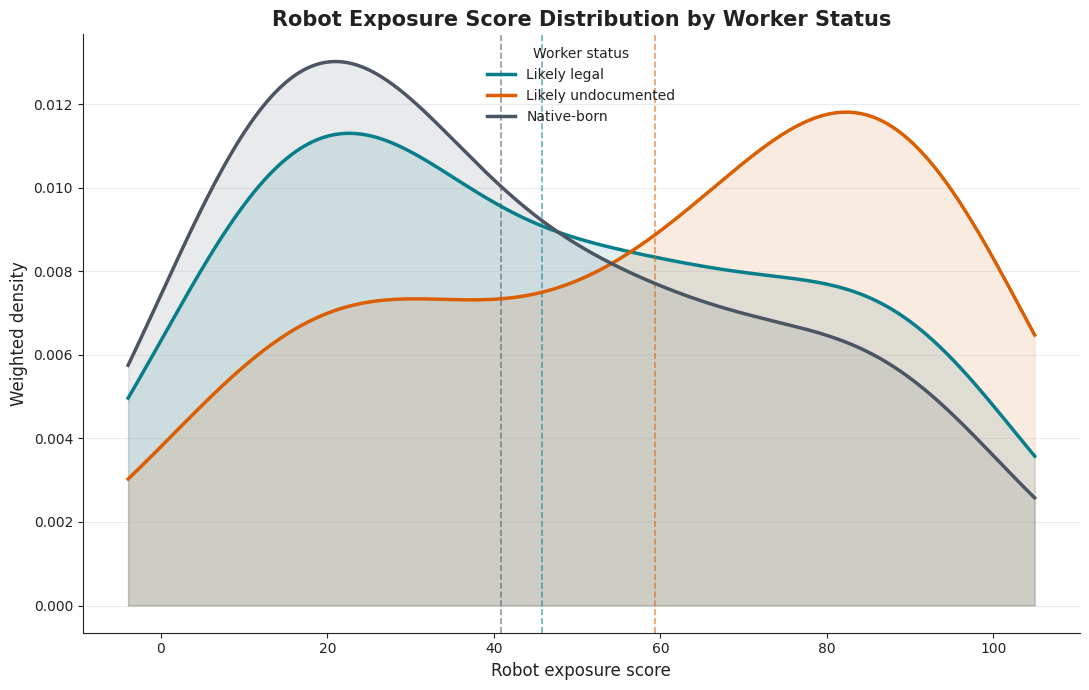

Loaded 338 pct_robot exposure scores from data\exposure_by_occ1990dd_lswt2010.xls.
Saved robot exposure status summary to outputs\tables\robot_exposure_pct_robot_by_worker_status_summary.csv.
Saved figure to outputs\figures\robot_exposure_kde_by_worker_status.png and outputs\figures\robot_exposure_kde_by_worker_status.svg.


,worker_status,unweighted_workers_with_score,weighted_workers,weighted_workers_with_score,score_coverage_pct,weighted_mean_pct_robot
0,Likely legal,817828,20706950.0,19686822.0,95.073499,45.736224
1,Likely undocumented,268231,8097205.0,7565594.0,93.434636,59.391764
2,Native-born,5303542,121211585.0,114960486.0,94.842821,40.887138


In [28]:
# Read/map pct_robot exposure scores and print average robot exposure by worker status.
# The exposure file is keyed by occ1990dd, so this requires OCC1990DD/OCC1990 in the ACS extract
# or a crosswalk from OCC/OCC2010 to occ1990dd.
%run -i scripts/robot_exposure_scores.py

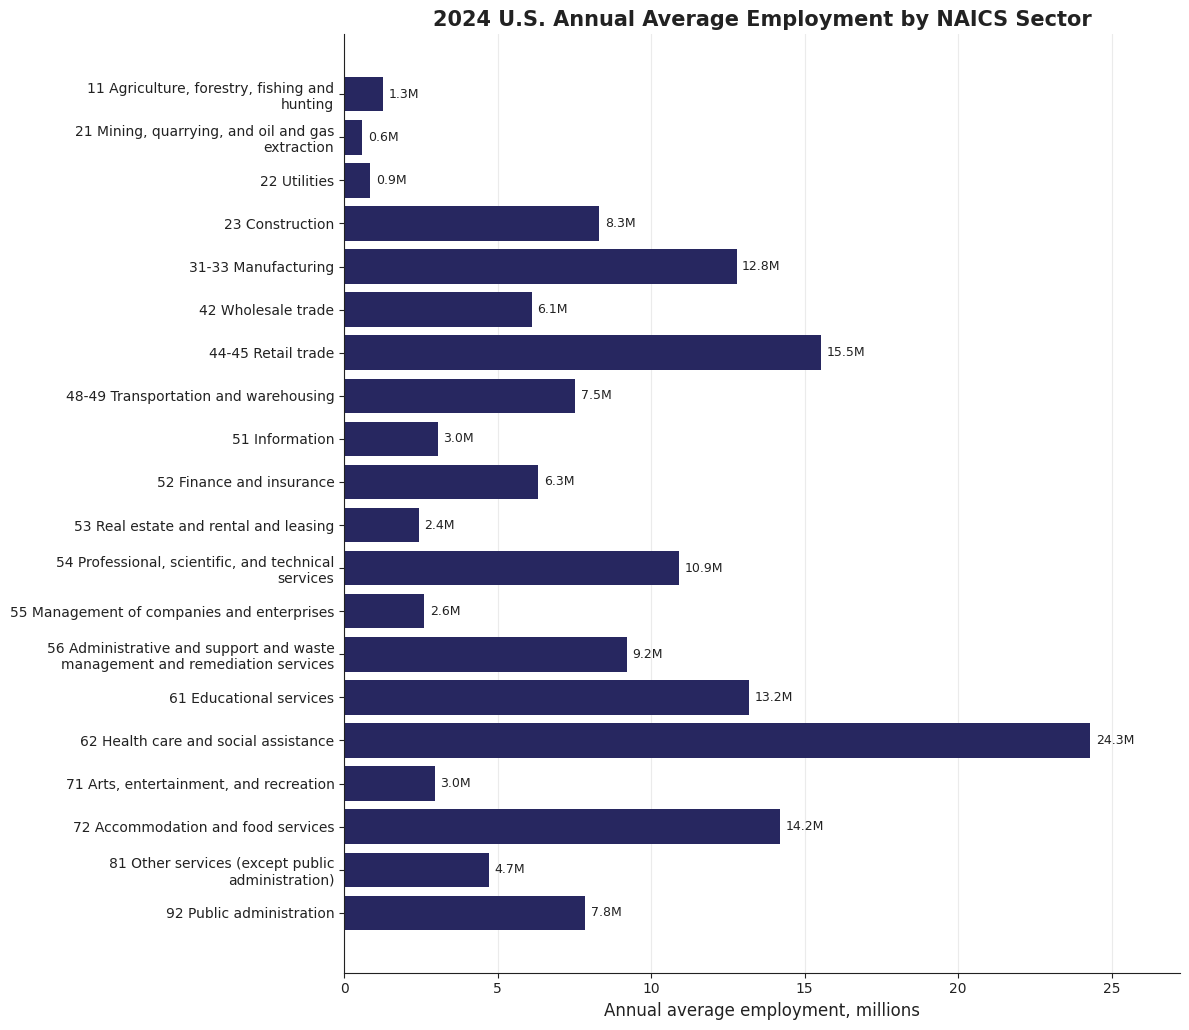

Loaded 20 two-digit NAICS sectors from C:\Users\linds\repos\Unidos\data\2024.annual.by_industry.
Saved table to C:\Users\linds\repos\Unidos\outputs\tables\qcew_2024_us_annual_avg_employment_by_naics_sector.csv.
Saved figure to C:\Users\linds\repos\Unidos\outputs\figures\qcew_2024_us_annual_avg_employment_by_naics_sector.png and C:\Users\linds\repos\Unidos\outputs\figures\qcew_2024_us_annual_avg_employment_by_naics_sector.svg.


,naics_code,industry_short_title,annual_avg_employment,annual_avg_employment_millions,ownership_rows_summed
0,11,"Agriculture, forestry, fishing and hunting",1259402,1.26,Federal Government; Local Government; Private;...
1,21,"Mining, quarrying, and oil and gas extraction",587151,0.59,Local Government; Private
2,22,Utilities,856308,0.86,Federal Government; Local Government; Private;...
3,23,Construction,8317572,8.32,Federal Government; Local Government; Private;...
4,31-33,Manufacturing,12784104,12.78,Federal Government; Local Government; Private;...
5,42,Wholesale trade,6107071,6.11,Federal Government; Local Government; Private
6,44-45,Retail trade,15529520,15.53,Federal Government; Local Government; Private;...
7,48-49,Transportation and warehousing,7532742,7.53,Federal Government; Local Government; Private;...
8,51,Information,3044132,3.04,Federal Government; Local Government; Private;...
9,52,Finance and insurance,6327482,6.33,Federal Government; Local Government; Private;...


In [29]:
%run -i scripts/qcew_annual_employment_by_naics_sector.py

### Undocumented Wages by Average Establishment Size

This sector-level view links ACS likely undocumented workers to QCEW average establishment size. The local QCEW files only include all-size rows, so establishment size is measured as annual average employment divided by annual average establishments within each NAICS sector.

In [ ]:
import runpy
from IPython.display import Image, display

undoc_establishment_size_globals = runpy.run_path(
    "scripts/undocumented_wages_by_establishment_size.py",
    init_globals={
        "foreign_born_df": foreign_born_df,
        "ipums_df": ipums_df,
        "WEIGHT_COL": WEIGHT_COL,
        "VALDOS_COLORS": VALDOS_COLORS,
        "UNDOC_ESTAB_SHOW_FIGURE": False,
    },
    run_name="__main__",
)

undocumented_wages_establishment_size = undoc_establishment_size_globals[
    "undocumented_wages_establishment_size"
]
undoc_establishment_size_png = undoc_establishment_size_globals["OUTPUT_PNG"]

display(Image(filename=str(undoc_establishment_size_png)))
display(undocumented_wages_establishment_size)
